<a href="https://colab.research.google.com/github/JesusArevalo16/NCAA-Prediction-Project/blob/main/Modelo_relacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MODELO RELACIONAL

# Modelo Relacional del Proyecto

El proyecto utiliza un modelo relacional normalizado para almacenar
la información histórica del torneo NCAA Women’s Basketball.

Las principales entidades identificadas son:

- Teams
- Seasons
- RegularSeasonResults
- TournamentResults
- Seeds

La normalización se realizó siguiendo principios de 3FN
(Tercera Forma Normal), evitando redundancia y asegurando integridad.

Posteriormente, para Machine Learning, se genera un dataset
desnormalizado de matchups optimizado para entrenamiento.

In [1]:
import sqlite3

In [4]:
import pandas as pd

## Cargar Datos

Vamos a cargar los datos de los diferentes archivos CSV en DataFrames de pandas. Asegúrate de que los archivos CSV estén disponibles en las rutas especificadas.

In [7]:
# Cargar los DataFrames (asegúrate de que los archivos CSV existan en estas rutas)
# IMPORTANT: Replace 'your_path_to_...' with the actual paths to your CSV files.
teams = pd.read_csv('/content/WTeams.csv')
reg_compact = pd.read_csv('/content/WRegularSeasonCompactResults.csv')
tourney = pd.read_csv('/content/WNCAATourneyCompactResults.csv')
seeds_df = pd.read_csv('/content/WNCAATourneySeeds.csv')

print("DataFrames cargados correctamente.")

DataFrames cargados correctamente.


In [2]:
# Crear base SQLite

conn = sqlite3.connect("ncaa_women.db")

print("Base de datos SQLite creada correctamente")

Base de datos SQLite creada correctamente


In [8]:
# Exportar DataFrames a SQLite

teams.to_sql("Teams", conn, if_exists="replace", index=False)

reg_compact.to_sql(
    "RegularSeasonResults",
    conn,
    if_exists="replace",
    index=False
)

tourney.to_sql(
    "TournamentResults",
    conn,
    if_exists="replace",
    index=False
)

seeds_df.to_sql(
    "Seeds",
    conn,
    if_exists="replace",
    index=False
)

print("Tablas exportadas correctamente")

Tablas exportadas correctamente


In [9]:
teams.to_sql(
    "Teams",
    conn,
    if_exists="replace",
    index=False
)

print("Tabla Teams guardada")

Tabla Teams guardada


In [10]:
reg_compact.to_sql(
    "RegularSeason",
    conn,
    if_exists="replace",
    index=False
)

print("Tabla RegularSeason guardada")

Tabla RegularSeason guardada


In [11]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,RegularSeasonResults
1,TournamentResults
2,Seeds
3,Teams
4,RegularSeason


In [12]:
teams.isnull().sum()

,0
TeamID,0
TeamName,0


In [13]:
teams.duplicated().sum()

np.int64(0)

In [14]:
(reg_compact["WScore"] <= reg_compact["LScore"]).sum()

np.int64(0)

In [15]:
# Valores nulos por columna

nulls = reg_compact.isnull().sum()

print(nulls)

Season     0
DayNum     0
WTeamID    0
WScore     0
LTeamID    0
LScore     0
WLoc       0
NumOT      0
dtype: int64


In [16]:
# Revisar duplicados

duplicates = reg_compact.duplicated().sum()

print("Duplicados:", duplicates)

Duplicados: 0


In [17]:
# Verificar que el ganador tenga más puntos

invalid_scores = (
    reg_compact["WScore"] <= reg_compact["LScore"]
).sum()

print("Resultados inválidos:", invalid_scores)

Resultados inválidos: 0


In [18]:
quality_report = pd.DataFrame({
    "Métrica": [
        "Valores nulos",
        "Duplicados",
        "Scores inválidos"
    ],
    "Resultado": [
        nulls.sum(),
        duplicates,
        invalid_scores
    ]
})

quality_report

,Métrica,Resultado
0,Valores nulos,0
1,Duplicados,0
2,Scores inválidos,0


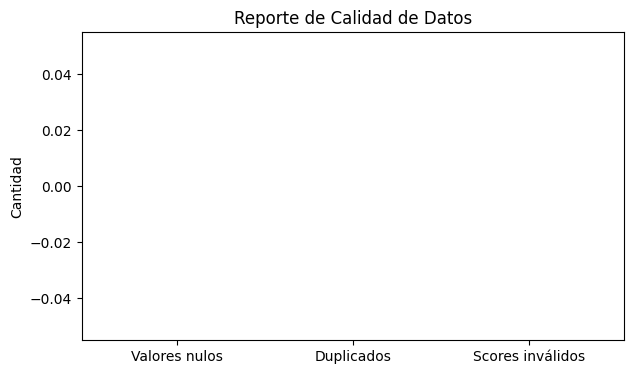

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.bar(
    quality_report["Métrica"],
    quality_report["Resultado"]
)

plt.title("Reporte de Calidad de Datos")

plt.ylabel("Cantidad")

plt.show()

In [21]:
comparison = pd.DataFrame({
    "Tecnología": [
        "SQLite",
        "PostgreSQL",
        "MongoDB"
    ],

    "Tipo": [
        "Relacional local",
        "Relacional cloud",
        "No relacional"
    ],

    "Ventaja": [
        "Ligero y fácil de usar",
        "Escalable y multiusuario",
        "Flexible para datos no estructurados"
    ],

    "Desventaja": [
        "No escala bien",
        "Configuración más compleja",
        "Menor integridad relacional"
    ],

    "Uso en el proyecto": [
        "Pruebas locales y ETL",
        "Producción y almacenamiento cloud",
        "Rankings y estadísticas avanzadas"
    ]
})

comparison

,Tecnología,Tipo,Ventaja,Desventaja,Uso en el proyecto
0,SQLite,Relacional local,Ligero y fácil de usar,No escala bien,Pruebas locales y ETL
1,PostgreSQL,Relacional cloud,Escalable y multiusuario,Configuración más compleja,Producción y almacenamiento cloud
2,MongoDB,No relacional,Flexible para datos no estructurados,Menor integridad relacional,Rankings y estadísticas avanzadas


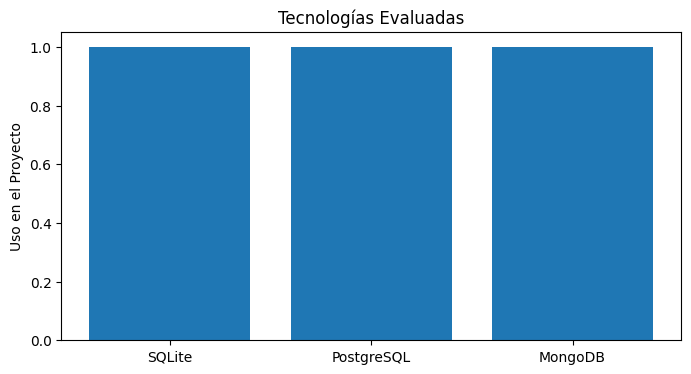

In [22]:
plt.figure(figsize=(8,4))

plt.bar(
    comparison["Tecnología"],
    [1,1,1]
)

plt.title("Tecnologías Evaluadas")

plt.ylabel("Uso en el Proyecto")

plt.show()

# Proceso ETL del Proyecto

El proyecto implementa un proceso ETL
(Extract, Transform, Load) para preparar
los datos históricos del torneo NCAA.

## Extract
Se extrajeron archivos CSV desde Kaggle.

## Transform
Se limpiaron datos, calcularon métricas
como Elo Rating, WinRate y estadísticas
por equipo.

## Load
Los datos transformados se cargaron
a SQLite y posteriormente se utilizaron
para Machine Learning.

In [23]:
print("""
ETL COMPLETADO

1. Datos extraídos desde Kaggle
2. Datos transformados con pandas
3. Features generadas
4. Datos cargados a SQLite
5. Dataset preparado para Machine Learning
""")


ETL COMPLETADO

1. Datos extraídos desde Kaggle
2. Datos transformados con pandas
3. Features generadas
4. Datos cargados a SQLite
5. Dataset preparado para Machine Learning



# Modelos de Datos Utilizados

## Modelo Relacional
Se utilizó SQLite para almacenar datos estructurados
como equipos, temporadas y resultados de partidos.

## Modelo No Relacional
MongoDB puede utilizarse para almacenar estadísticas
flexibles como rankings Massey y métricas avanzadas.

## Modelo Semántico
Las relaciones entre equipos, temporadas y torneos
pueden representarse mediante grafos semánticos.

In [24]:
import networkx as nx

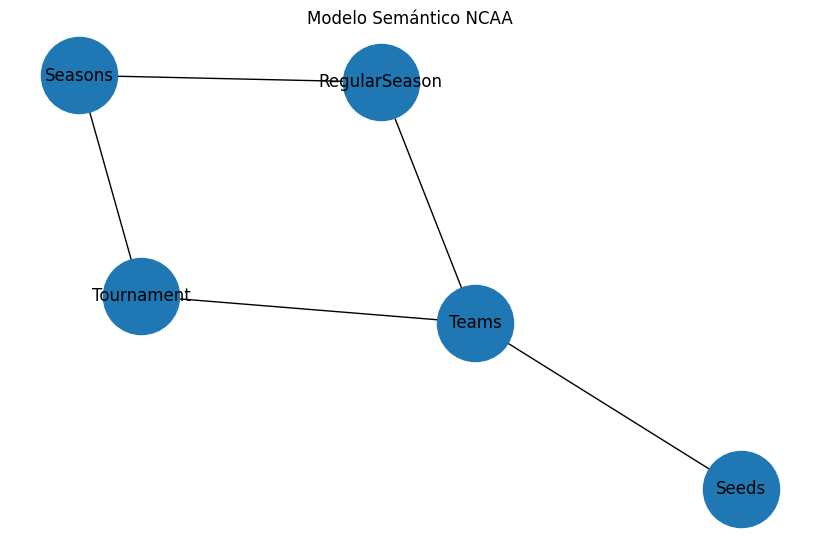

In [25]:
G = nx.Graph()

G.add_edge("Teams", "RegularSeason")
G.add_edge("Teams", "Tournament")
G.add_edge("Teams", "Seeds")
G.add_edge("Seasons", "RegularSeason")
G.add_edge("Seasons", "Tournament")

plt.figure(figsize=(8,5))

nx.draw(
    G,
    with_labels=True,
    node_size=3000
)

plt.title("Modelo Semántico NCAA")

plt.show()

In [26]:
spark_compare = pd.DataFrame({
    "Herramienta": [
        "Pandas",
        "PySpark"
    ],

    "Ventaja": [
        "Fácil de usar",
        "Procesamiento distribuido"
    ],

    "Desventaja": [
        "Limitado en Big Data",
        "Más complejo"
    ],

    "Uso recomendado": [
        "Datasets pequeños y medianos",
        "Millones de registros"
    ]
})

spark_compare

,Herramienta,Ventaja,Desventaja,Uso recomendado
0,Pandas,Fácil de usar,Limitado en Big Data,Datasets pequeños y medianos
1,PySpark,Procesamiento distribuido,Más complejo,Millones de registros


# Recolección de Datos

Los datos fueron obtenidos desde la plataforma Kaggle,
utilizando archivos CSV oficiales de la competencia
March Machine Learning Mania 2026.

La información incluye:

- Equipos
- Resultados históricos
- Seeds del torneo
- Matchups NCAA

La recolección se realizó mediante descarga directa
de datasets públicos.